In [4]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

#### Partie 1 : chargement et exploration

In [5]:
data = pd.read_csv('./titanic/train.csv')
data.head() # afficher les 5 premières lignes

,PassengerId,Survived,Pclass,Name,Sex,Age,SibSp,Parch,Ticket,Fare,Cabin,Embarked
0,1,0,3,"Braund, Mr. Owen Harris",male,22.0,1,0,A/5 21171,7.2500,NaN,S
1,2,1,1,"Cumings, Mrs. John Bradley (Florence Briggs Th...",female,38.0,1,0,PC 17599,71.2833,C85,C
2,3,1,3,"Heikkinen, Miss. Laina",female,26.0,0,0,STON/O2. 3101282,7.9250,NaN,S
3,4,1,1,"Futrelle, Mrs. Jacques Heath (Lily May Peel)",female,35.0,1,0,113803,53.1000,C123,S
4,5,0,3,"Allen, Mr. William Henry",male,35.0,0,0,373450,8.0500,NaN,S


In [6]:
data.dtypes # afficher les types de données

PassengerId      int64
Survived         int64
Pclass           int64
Name            object
Sex             object
Age            float64
SibSp            int64
Parch            int64
Ticket          object
Fare           float64
Cabin           object
Embarked        object
dtype: object

In [7]:
passagers = data.shape[0] # nombre de passager
print(f"Nombre de passager : {passagers}")

Nombre de passager : 891


In [8]:
survivants = data.loc[data['Survived'] == 1].shape[0]
print(f"Nombre de survivants : {survivants}")

Nombre de survivants : 342


In [9]:
proportion = survivants / passagers
print(f"Proportion : {proportion:.2f}")
print(f"Proportion : {data['Survived'].mean():.2f}")

Proportion : 0.38
Proportion : 0.38


##### Identifier les colonnes avec des valeurs manquantes

In [10]:
valeurs_manquantes = data.isnull().sum() # valeurs manquantes par colonne
pourcentages = 100 * (valeurs_manquantes / len(data))
colonnes_na = valeurs_manquantes[valeurs_manquantes > 0] # filtrer, enlever les colonnes qui n'ont pas de valeurs manquantes

df_valeurs_manquantes = pd.DataFrame({'valeurs_manquantes': colonnes_na, 'pourcentages': pourcentages[colonnes_na.index].round(2)})

In [11]:
df_valeurs_manquantes

,valeurs_manquantes,pourcentages
Age,177,19.87
Cabin,687,77.10
Embarked,2,0.22


#### Partie 2 : Nettoyage et préparation

In [12]:
# imputer les valeurs manquantes : Age par la médiane, Embarked par la modalité la plus fréquente
age_mediane = data['Age'].median()
print(f"Médiane âge : {age_mediane}")

data['Age'] = data['Age'].fillna(age_mediane)

Médiane âge : 28.0


In [13]:
modalite_embarked = data['Embarked'].mode()[0] # modalité = valeur la plus fréquente
print(f"Modalité embarked : {modalite_embarked}")

data['Embarked'] = data['Embarked'].fillna(modalite_embarked)

Modalité embarked : S


In [14]:
print(data[['Age', 'Embarked']].isnull().sum()) # vérification des valeurs manquantes

Age         0
Embarked    0
dtype: int64


In [15]:
# supprimer les colonnes inutiles : PassengerId, Name, Ticket, Cabin. 
data['Title'] = data['Name'].str.extract(r',\s*([^\.]+)\.')

data.drop(columns=['PassengerId', 'Name', 'Ticket', 'Cabin'], inplace=True)

* La colonne 'PassengerId' représente un identifiant unique pour chaque passager mais ne contient aucune information qui pourrait être utile à la prédiction
* La colonne 'Name' est un texte brut, donc n'apport aucune infomation pertinente ou utilise à la prédiction
* La colonne 'Ticket' contient des numéros de billets qui peuvent être incohérents, ces numéros sont très peu informatifs pour une prédiction de survie, surtout sans contexte
* La colonne 'Cabin' est la colonne qui contient le plus de valeurs manquantes parmi toutes les autres colonnes, donc difficiles à exploiter sans traitement de toutes ces valeurs manquantes

In [16]:
data.head()

,Survived,Pclass,Sex,Age,SibSp,Parch,Fare,Embarked,Title
0,0,3,male,22.0,1,0,7.2500,S,Mr
1,1,1,female,38.0,1,0,71.2833,C,Mrs
2,1,3,female,26.0,0,0,7.9250,S,Miss
3,1,1,female,35.0,1,0,53.1000,S,Mrs
4,0,3,male,35.0,0,0,8.0500,S,Mr


In [17]:
# Créer une nouvelle variable Title à partir de Name
n_data = pd.read_csv('./titanic/train.csv')
n_data['Title'] = n_data['Name'].str.extract(r',\s*([^\.]+)\.')
print(n_data['Title'].value_counts())

Title
Mr              517
Miss            182
Mrs             125
Master           40
Dr                7
Rev               6
Mlle              2
Major             2
Col               2
the Countess      1
Capt              1
Ms                1
Sir               1
Lady              1
Mme               1
Don               1
Jonkheer          1
Name: count, dtype: int64


* 'Title' indique le genre, la classe sociale et parfois l'âge du passage; cette colonne peut aider à améliorer la prédiction de survie

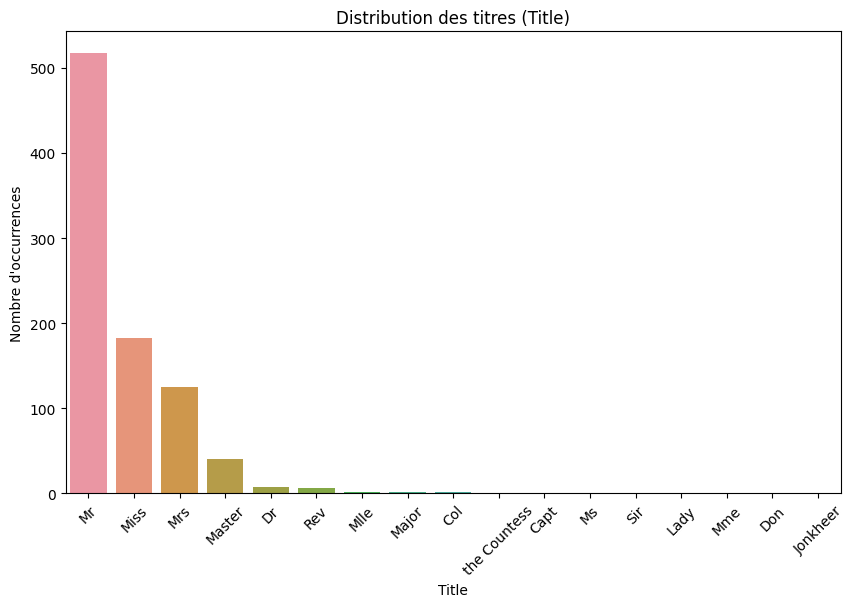

In [18]:
plt.figure(figsize=(10, 6))

sns.countplot(data=data, x='Title', order=data['Title'].value_counts().index)

plt.title("Distribution des titres (Title)")
plt.xlabel("Title")
plt.ylabel("Nombre d'occurrences")
plt.xticks(rotation=45)
plt.show()

#### Partie 3 : Encodage & Prétraitement
Encoder les variables catégorielles (Sex, Embarked, Title) à l'aide de LabelEncoder ou OneHotEncoder. Tester les 2 méthodes

In [19]:
from sklearn.preprocessing import LabelEncoder, OneHotEncoder

In [20]:
# avec LabelEncoder - transforme chaque catégorie en un entier
data_le = data.copy()
le = LabelEncoder()

for col in ['Sex', 'Embarked', 'Title']:
    data_le[col] = le.fit_transform(data_le[col])
    
print(data_le[['Sex', 'Embarked', 'Title']].head())

   Sex  Embarked  Title
0    1         2     11
1    0         0     12
2    0         2      8
3    0         2     12
4    1         2     11


In [21]:
# avec OneHotEncoder - crée une colonne binaire pour chaque modalité
data_ohe = data.copy()
ohe = OneHotEncoder(sparse=False, drop='first')

encoded_cols = ohe.fit_transform(data_ohe[['Sex', 'Embarked', 'Title']])
new_col_names = ohe.get_feature_names_out(['Sex', 'Embarked', 'Title'])

encoded_df = pd.DataFrame(encoded_cols, columns=new_col_names, index=data_ohe.index)
data_ohe = pd.concat([data_ohe.drop(columns=['Sex', 'Embarked', 'Title']), encoded_df], axis=1)

data_ohe.head()

C:\Users\Laura Ophélie\AppData\Local\Programs\Python\Python310\lib\site-packages\sklearn\preprocessing\_encoders.py:868: FutureWarning: `sparse` was renamed to `sparse_output` in version 1.2 and will be removed in 1.4. `sparse_output` is ignored unless you leave `sparse` to its default value.
  warnings.warn(


,Survived,Pclass,Age,SibSp,Parch,Fare,Sex_male,Embarked_Q,Embarked_S,Title_Col,...,Title_Master,Title_Miss,Title_Mlle,Title_Mme,Title_Mr,Title_Mrs,Title_Ms,Title_Rev,Title_Sir,Title_the Countess
0,0,3,22.0,1,0,7.2500,1.0,0.0,1.0,0.0,...,0.0,0.0,0.0,0.0,1.0,0.0,0.0,0.0,0.0,0.0
1,1,1,38.0,1,0,71.2833,0.0,0.0,0.0,0.0,...,0.0,0.0,0.0,0.0,0.0,1.0,0.0,0.0,0.0,0.0
2,1,3,26.0,0,0,7.9250,0.0,0.0,1.0,0.0,...,0.0,1.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0
3,1,1,35.0,1,0,53.1000,0.0,0.0,1.0,0.0,...,0.0,0.0,0.0,0.0,0.0,1.0,0.0,0.0,0.0,0.0
4,0,3,35.0,0,0,8.0500,1.0,0.0,1.0,0.0,...,0.0,0.0,0.0,0.0,1.0,0.0,0.0,0.0,0.0,0.0


In [22]:
data

,Survived,Pclass,Sex,Age,SibSp,Parch,Fare,Embarked,Title
0,0,3,male,22.0,1,0,7.2500,S,Mr
1,1,1,female,38.0,1,0,71.2833,C,Mrs
2,1,3,female,26.0,0,0,7.9250,S,Miss
3,1,1,female,35.0,1,0,53.1000,S,Mrs
4,0,3,male,35.0,0,0,8.0500,S,Mr
...,...,...,...,...,...,...,...,...,...
886,0,2,male,27.0,0,0,13.0000,S,Rev
887,1,1,female,19.0,0,0,30.0000,S,Miss
888,0,3,female,28.0,1,2,23.4500,S,Miss
889,1,1,male,26.0,0,0,30.0000,C,Mr


In [23]:
le = LabelEncoder()

for col in ['Sex', 'Embarked', 'Title']:
    data[col] = le.fit_transform(data[col])
    
print(data[['Sex', 'Embarked', 'Title']].head())

data

   Sex  Embarked  Title
0    1         2     11
1    0         0     12
2    0         2      8
3    0         2     12
4    1         2     11


,Survived,Pclass,Sex,Age,SibSp,Parch,Fare,Embarked,Title
0,0,3,1,22.0,1,0,7.2500,2,11
1,1,1,0,38.0,1,0,71.2833,0,12
2,1,3,0,26.0,0,0,7.9250,2,8
3,1,1,0,35.0,1,0,53.1000,2,12
4,0,3,1,35.0,0,0,8.0500,2,11
...,...,...,...,...,...,...,...,...,...
886,0,2,1,27.0,0,0,13.0000,2,14
887,1,1,0,19.0,0,0,30.0000,2,8
888,0,3,0,28.0,1,2,23.4500,2,8
889,1,1,1,26.0,0,0,30.0000,0,11


* LabelEncoder = plus simple, garde une colonne par variables
* OneHotEncoder = crée autant de colonne que de catégories avec les valeurs 0 ou 1 : 1 = présence, 0 = absence

Standardisez Age et Fare avec StandardScaler. Pourquoi cette étape peut-elle être utile même
avec des arbres ?

In [24]:
# standardisation avec StandardScaler
from sklearn.preprocessing import StandardScaler

data_scaled = data.copy()
scaler = StandardScaler()

data_scaled[['Age', 'Fare']] = scaler.fit_transform(data_scaled[['Age', 'Fare']])
print(data_scaled[['Age', 'Fare']].head())

        Age      Fare
0 -0.565736 -0.502445
1  0.663861  0.786845
2 -0.258337 -0.488854
3  0.433312  0.420730
4  0.433312 -0.486337


In [25]:
scaler = StandardScaler()

data[['Age', 'Fare']] = scaler.fit_transform(data[['Age', 'Fare']])
print(data[['Age', 'Fare']].head())

data

        Age      Fare
0 -0.565736 -0.502445
1  0.663861  0.786845
2 -0.258337 -0.488854
3  0.433312  0.420730
4  0.433312 -0.486337


,Survived,Pclass,Sex,Age,SibSp,Parch,Fare,Embarked,Title
0,0,3,1,-0.565736,1,0,-0.502445,2,11
1,1,1,0,0.663861,1,0,0.786845,0,12
2,1,3,0,-0.258337,0,0,-0.488854,2,8
3,1,1,0,0.433312,1,0,0.420730,2,12
4,0,3,1,0.433312,0,0,-0.486337,2,11
...,...,...,...,...,...,...,...,...,...
886,0,2,1,-0.181487,0,0,-0.386671,2,14
887,1,1,0,-0.796286,0,0,-0.044381,2,8
888,0,3,0,-0.104637,1,2,-0.176263,2,8
889,1,1,1,-0.258337,0,0,-0.044381,0,11


Divisez le dataset en X et y. Cible = Survived. Faites un train_test_split (70/30) avec
random_state=42

In [26]:
from sklearn.model_selection import train_test_split

In [27]:
y = data['Survived']
X = data.drop(columns=['Survived'])

X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.3, random_state=42
)

#### Partie 4 – Visualisation & Analyse Exploratoire

Affichez la heatmap des corrélations. Quelles sont les variables les plus corrélées avec Survived ?

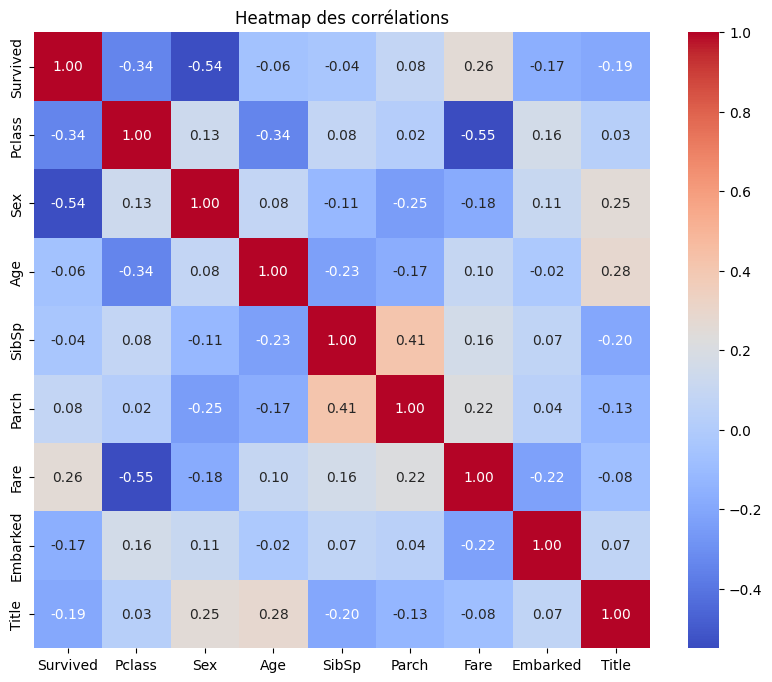

In [28]:
corr_matrix = data.corr(numeric_only=True) # matrice de correlation sur les colonnes numériques

# heatmap
plt.figure(figsize=(10, 8))

sns.heatmap(corr_matrix, annot=True, fmt=".2f", cmap="coolwarm", square=True)

plt.title("Heatmap des corrélations")
plt.show()

In [29]:
correlation_with_survived = corr_matrix['Survived'].sort_values(ascending=False)
print(correlation_with_survived)

Survived    1.000000
Fare        0.257307
Parch       0.081629
SibSp      -0.035322
Age        -0.064910
Embarked   -0.167675
Title      -0.193635
Pclass     -0.338481
Sex        -0.543351
Name: Survived, dtype: float64


Réalisez des barplots de survie par Sex, Pclass, Embarked, et Title. Qu’en concluez-vous ?

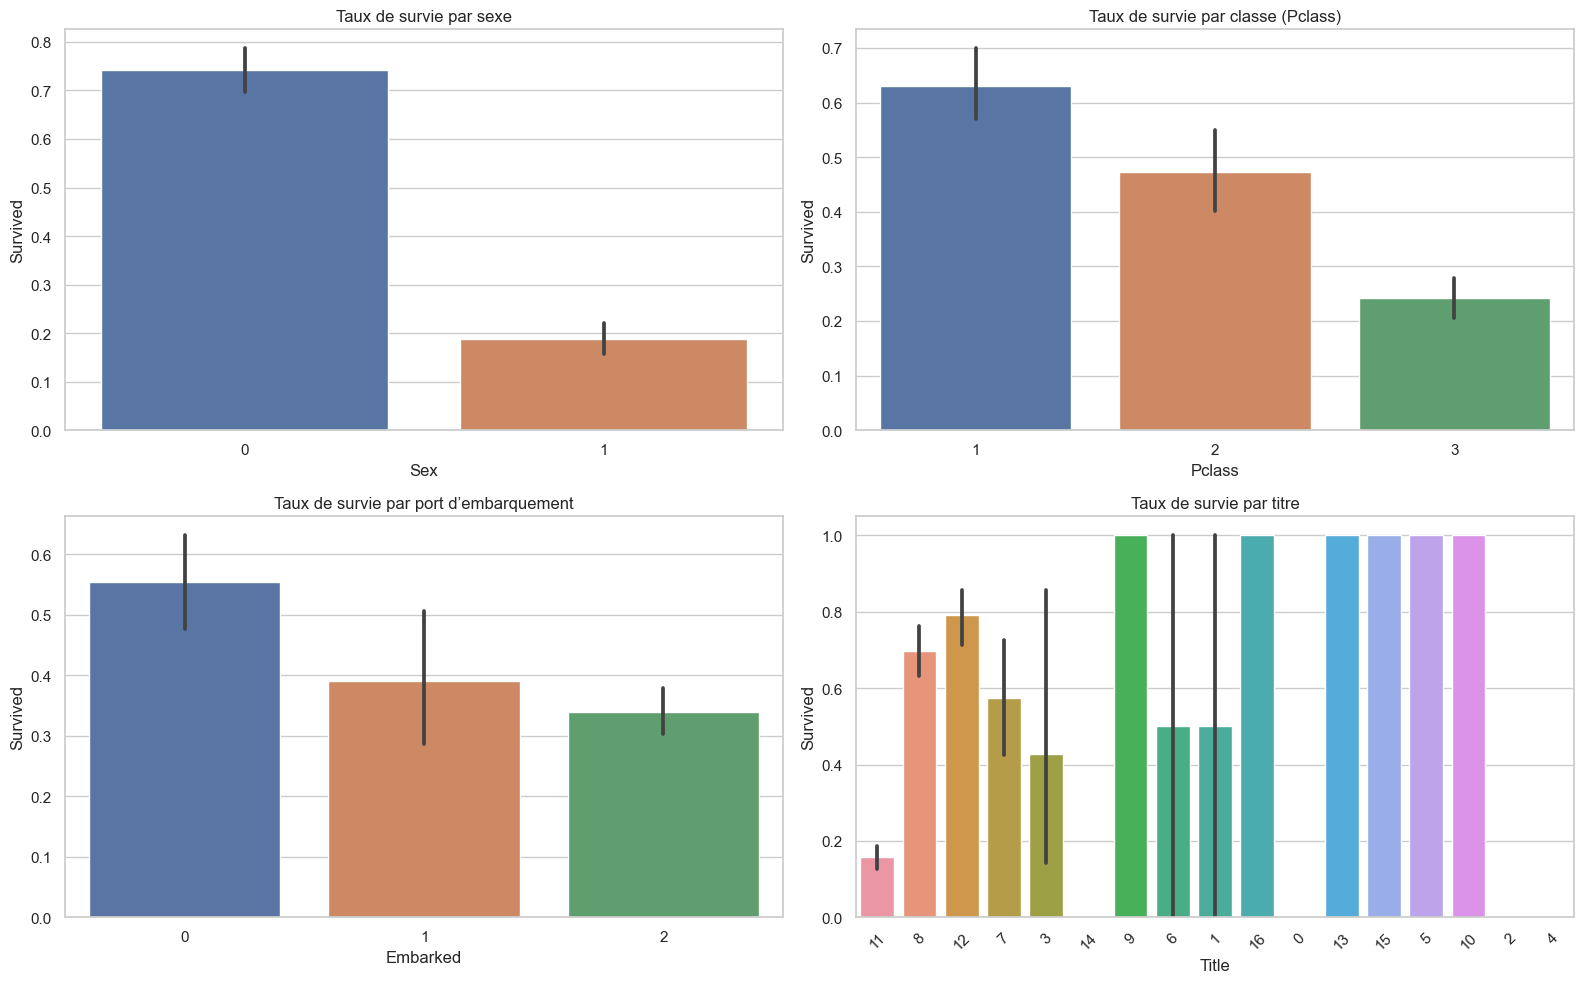

In [30]:
sns.set(style="whitegrid")
plt.figure(figsize=(16, 10))

plt.subplot(2, 2, 1)
sns.barplot(data=data, x='Sex', y='Survived')
plt.title('Taux de survie par sexe')

plt.subplot(2, 2, 2)
sns.barplot(data=data, x='Pclass', y='Survived')
plt.title('Taux de survie par classe (Pclass)')

plt.subplot(2, 2, 3)
sns.barplot(data=data, x='Embarked', y='Survived')
plt.title('Taux de survie par port d’embarquement')

plt.subplot(2, 2, 4)
sns.barplot(data=data, x='Title', y='Survived', order=data['Title'].value_counts().index)
plt.title('Taux de survie par titre')
plt.xticks(rotation=45)

plt.tight_layout()
plt.show()

#### Partie 5 : Arbre de décision
Entraînez un DecisionTreeClassifier (max_depth=4). Affichez l’arbre avec plot_tree ou
graphviz

In [31]:
from sklearn.tree import DecisionTreeClassifier, plot_tree

In [32]:
clf = DecisionTreeClassifier(max_depth=4, random_state=42)
clf.fit(X_train, y_train)

DecisionTreeClassifier(max_depth=4, random_state=42)

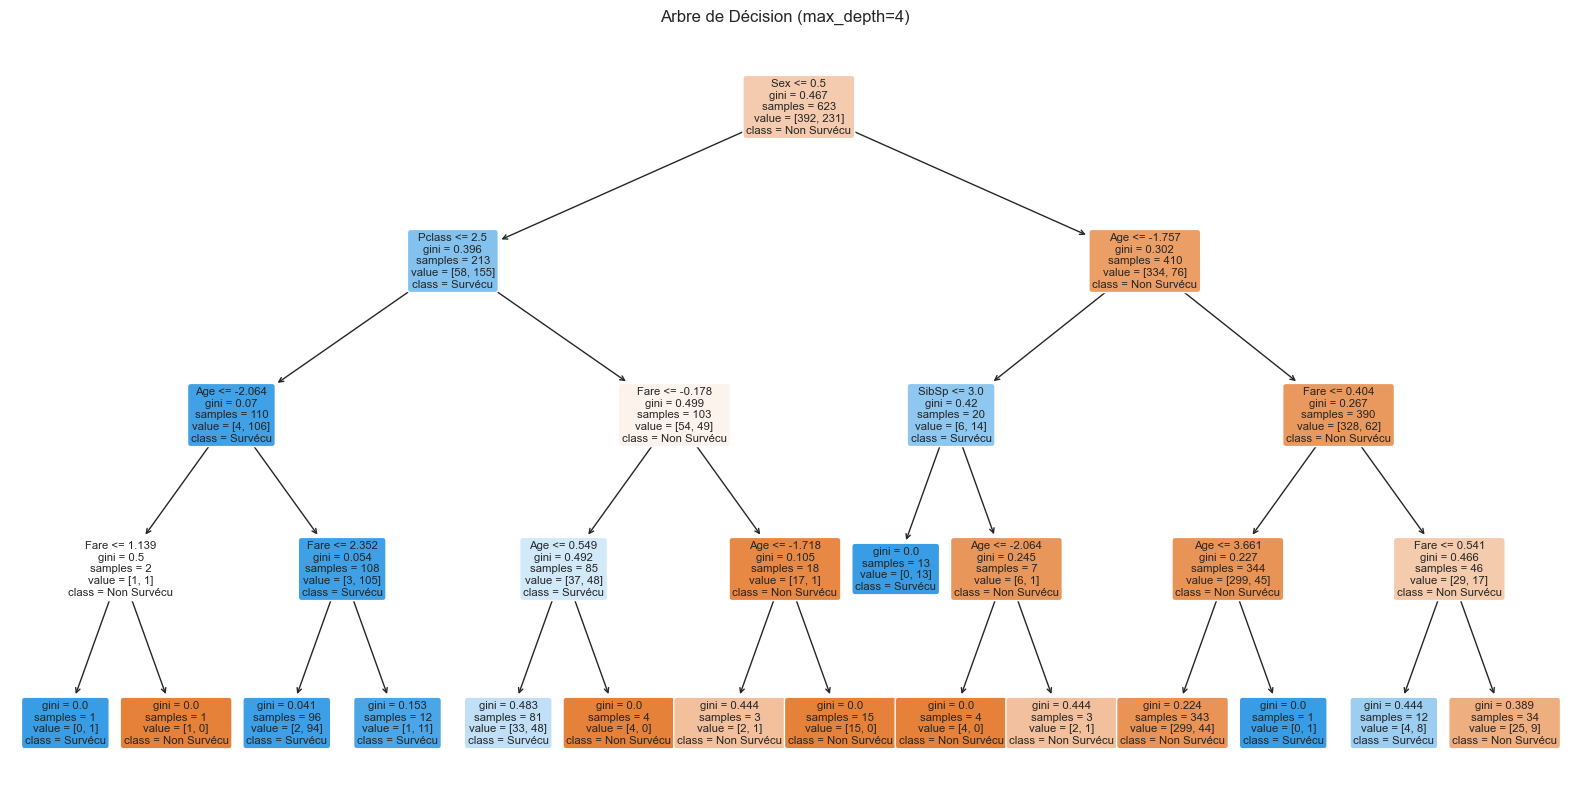

In [33]:
plt.figure(figsize=(20, 10))
plot_tree(clf, 
          feature_names=X_train.columns, 
          class_names=["Non Survécu", "Survécu"],
          filled=True,
          rounded=True)
plt.title("Arbre de Décision (max_depth=4)")
plt.show()

##### Evaluation du modèle

In [34]:
from sklearn.metrics import (
    accuracy_score,
    precision_score,
    recall_score,
    f1_score,
    confusion_matrix,
    ConfusionMatrixDisplay,
    roc_curve,
    auc,
    RocCurveDisplay
)

In [35]:
# Prédiction
y_pred = clf.predict(X_test)
y_proba = clf.predict_proba(X_test)[:, 1]

In [36]:
# Accuracy
accuracy = accuracy_score(y_test, y_pred)

# Précision
precision = precision_score(y_test, y_pred)

# Rappel
recall = recall_score(y_test, y_pred)

# F1-score
f1 = f1_score(y_test, y_pred)

print(f"Accuracy  : {accuracy:.3f}")
print(f"Précision : {precision:.3f}")
print(f"Rappel    : {recall:.3f}")
print(f"F1-score  : {f1:.3f}")

Accuracy  : 0.821
Précision : 0.825
Rappel    : 0.721
F1-score  : 0.769


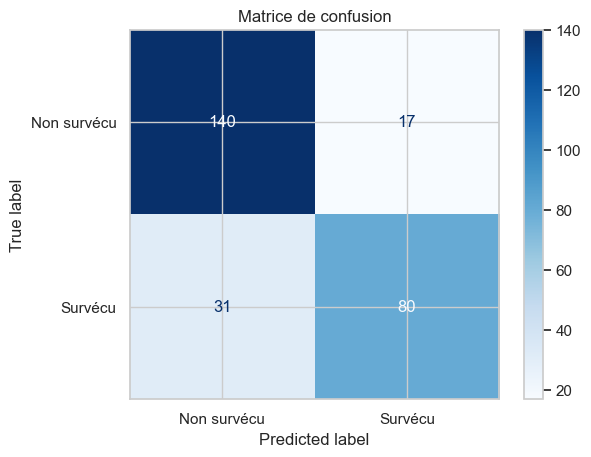

In [37]:
# Matrice de confusion
cm = confusion_matrix(y_test, y_pred)
disp = ConfusionMatrixDisplay(confusion_matrix=cm, display_labels=["Non survécu", "Survécu"])
disp.plot(cmap="Blues")
plt.title("Matrice de confusion")
plt.show()

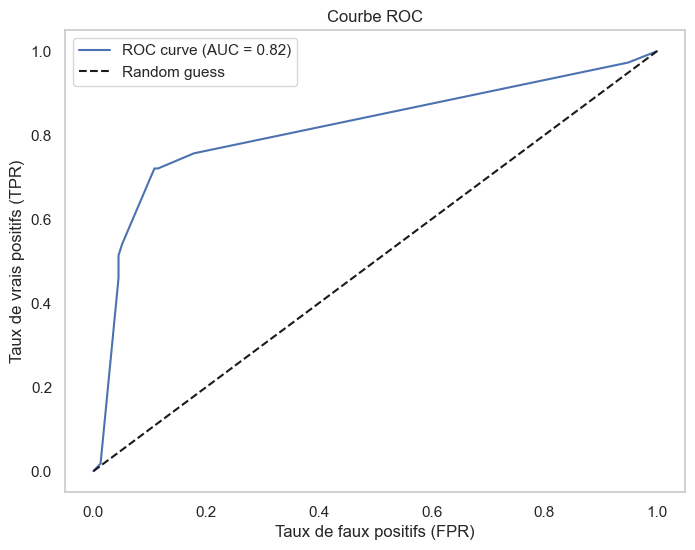

In [38]:
# Courbe ROC
fpr, tpr, thresholds = roc_curve(y_test, y_proba)
roc_auc = auc(fpr, tpr)

plt.figure(figsize=(8, 6))
plt.plot(fpr, tpr, label=f"ROC curve (AUC = {roc_auc:.2f})")
plt.plot([0, 1], [0, 1], "k--", label="Random guess")
plt.xlabel("Taux de faux positifs (FPR)")
plt.ylabel("Taux de vrais positifs (TPR)")
plt.title("Courbe ROC")
plt.legend()
plt.grid()
plt.show()

#### Partie 6 : Random Forest
Entraînez une RandomForestClassifier avec 100 arbres. Même split que précédemment.

In [39]:
from sklearn.ensemble import RandomForestClassifier

In [40]:
rf = RandomForestClassifier(n_estimators=100, random_state=42)
rf.fit(X_train, y_train)

RandomForestClassifier(random_state=42)

In [41]:
y_pred_rf = rf.predict(X_test)
y_proba_rf = rf.predict_proba(X_test)[:, 1]

In [42]:
acc_rf = accuracy_score(y_test, y_pred_rf)
prec_rf = precision_score(y_test, y_pred_rf)
rec_rf = recall_score(y_test, y_pred_rf)
f1_rf = f1_score(y_test, y_pred_rf)

print(f"Random Forest - Accuracy  : {acc_rf:.3f}")
print(f"Random Forest - Précision : {prec_rf:.3f}")
print(f"Random Forest - Rappel    : {rec_rf:.3f}")
print(f"Random Forest - F1-score  : {f1_rf:.3f}")

Random Forest - Accuracy  : 0.799
Random Forest - Précision : 0.771
Random Forest - Rappel    : 0.730
Random Forest - F1-score  : 0.750


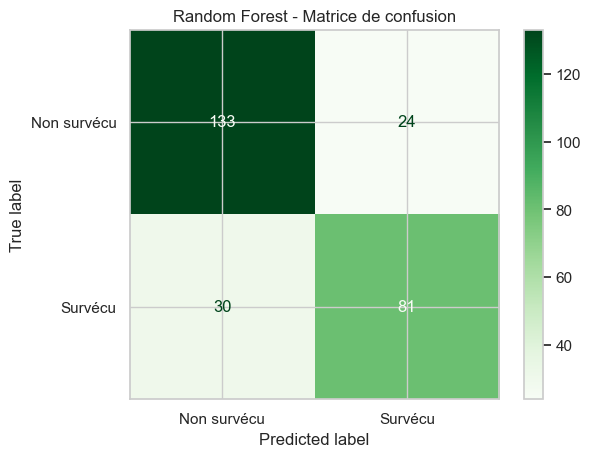

In [44]:
cm_rf = confusion_matrix(y_test, y_pred_rf)

disp_rf = ConfusionMatrixDisplay(confusion_matrix=cm_rf, display_labels=["Non survécu", "Survécu"])
disp_rf.plot(cmap="Greens")

plt.title("Random Forest - Matrice de confusion")
plt.show()

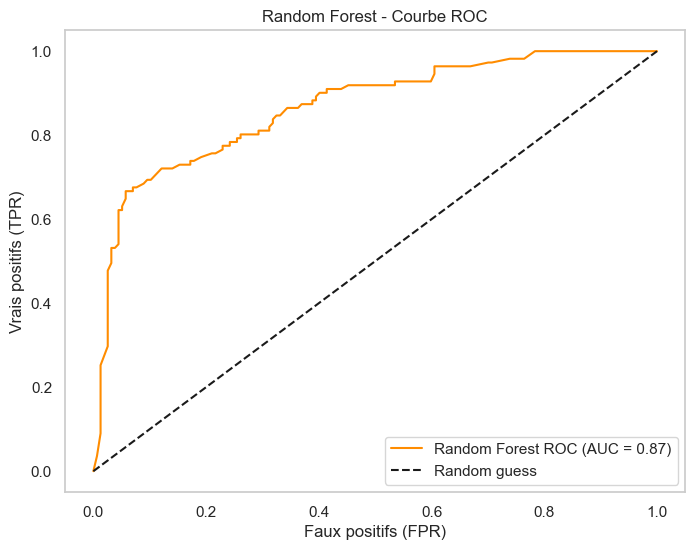

In [45]:
fpr_rf, tpr_rf, _ = roc_curve(y_test, y_proba_rf)
roc_auc_rf = auc(fpr_rf, tpr_rf)

plt.figure(figsize=(8, 6))
plt.plot(fpr_rf, tpr_rf, label=f"Random Forest ROC (AUC = {roc_auc_rf:.2f})", color="darkorange")
plt.plot([0, 1], [0, 1], "k--", label="Random guess")
plt.xlabel("Faux positifs (FPR)")
plt.ylabel("Vrais positifs (TPR)")
plt.title("Random Forest - Courbe ROC")
plt.legend()
plt.grid()
plt.show()

Comparez les performances de la Random Forest avec l’arbre de décision sur toutes les métriques.

Affichez feature_importances_. Quelles sont les 3 variables les plus importantes ?

In [51]:
importances = rf.feature_importances_
feature_names = X_train.columns

feat_importance = pd.Series(importances, index=feature_names).sort_values(ascending=False)
top3 = feat_importance.head(3)

print("3 variables les plus importantes : ")
print(top3)

3 variables les plus importantes : 
Fare    0.257038
Age     0.226435
Sex     0.204995
dtype: float64


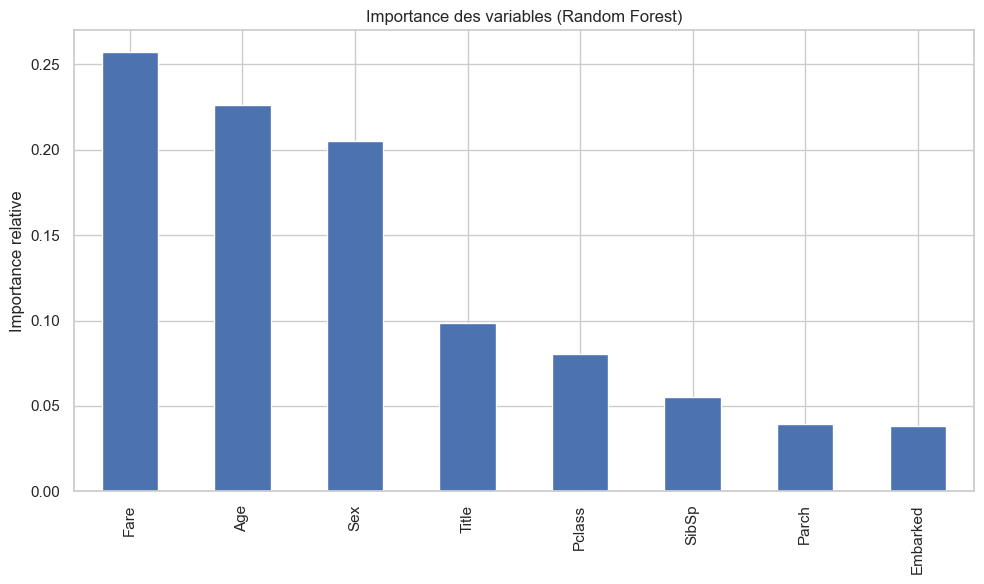

In [52]:
plt.figure(figsize=(10, 6))
feat_importance.plot(kind='bar')
plt.title("Importance des variables (Random Forest)")
plt.ylabel("Importance relative")
plt.tight_layout()
plt.show()

Variables les plus importantes :
* Sex : facteur le plus déterminant -> les femmes ont mieux survécus par rapport aux hommes
* Fare : tarif élevé -> souvent associé à une meilleur cabine -> meilleure survie
* Age : certains passagers de certains âge -> ont eu plus de chance d'être secourus -> plus de chance de survie

#### Partie 7 : Analyse et optimisation
Faites varier max_depth entre 1 et 10 pour l’arbre. Tracez l’évolution de l’accuracy en train/test

In [55]:
train_accuracies = []
test_accuracies = []
depths = range(1, 11)

for depth in depths:
    clf = DecisionTreeClassifier(max_depth=depth, random_state=42)
    clf.fit(X_train, y_train)

    train_acc = accuracy_score(y_train, clf.predict(X_train))
    test_acc = accuracy_score(y_test, clf.predict(X_test))

    train_accuracies.append(train_acc)
    test_accuracies.append(test_acc)

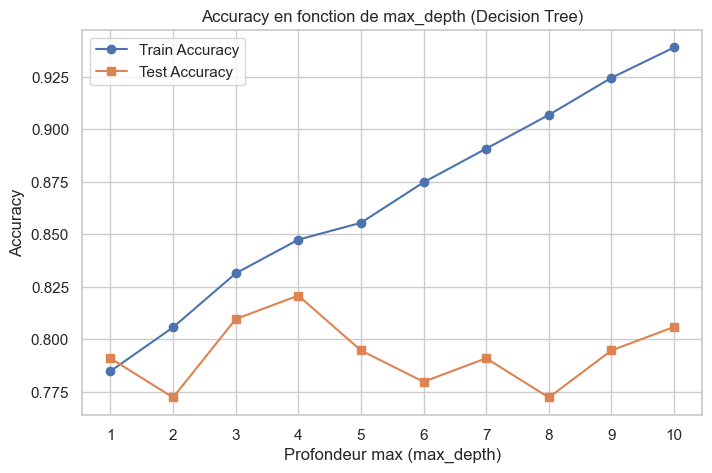

In [56]:
plt.figure(figsize=(8, 5))
plt.plot(depths, train_accuracies, label='Train Accuracy', marker='o')
plt.plot(depths, test_accuracies, label='Test Accuracy', marker='s')
plt.xlabel('Profondeur max (max_depth)')
plt.ylabel('Accuracy')
plt.title('Accuracy en fonction de max_depth (Decision Tree)')
plt.legend()
plt.grid(True)
plt.xticks(depths)
plt.show()

Utilisez cross_val_score pour comparer la stabilité des deux modèles.

In [57]:
from sklearn.model_selection import cross_val_score

In [59]:
dt = DecisionTreeClassifier(max_depth=4, random_state=42)
rf = RandomForestClassifier(n_estimators=100, random_state=42)

In [60]:
dt_scores = cross_val_score(dt, X, y, cv=5, scoring='accuracy')
rf_scores = cross_val_score(rf, X, y, cv=5, scoring='accuracy')

In [61]:
print("Decision Tree (max_depth=4)")
print(f"Mean Accuracy: {dt_scores.mean():.3f}")
print(f"Standard Deviation: {dt_scores.std():.3f}")

print("\nRandom Forest (100 arbres)")
print(f"Mean Accuracy: {rf_scores.mean():.3f}")
print(f"Standard Deviation: {rf_scores.std():.3f}")

Decision Tree (max_depth=4)
Mean Accuracy: 0.805
Standard Deviation: 0.029

Random Forest (100 arbres)
Mean Accuracy: 0.809
Standard Deviation: 0.033


Effectuez un GridSearchCV sur la Random Forest (max_depth, min_samples_split,
n_estimators). Quel est le meilleur modèle ?

In [62]:
from sklearn.model_selection import GridSearchCV

In [63]:
param_grid = {
    'max_depth': [3, 4, 5, 6, 8, None],
    'min_samples_split': [2, 5, 10],
    'n_estimators': [50, 100, 200]
}

In [69]:
rf = RandomForestClassifier(random_state=42)

In [70]:
grid_search = GridSearchCV(
    estimator=rf,
    param_grid=param_grid,
    cv=5,
    scoring='accuracy',
    n_jobs=-1,
    verbose=1
)
grid_search.fit(X, y)

Fitting 5 folds for each of 54 candidates, totalling 270 fits


GridSearchCV(cv=5, estimator=RandomForestClassifier(random_state=42), n_jobs=-1,
             param_grid={'max_depth': [3, 4, 5, 6, 8, None],
                         'min_samples_split': [2, 5, 10],
                         'n_estimators': [50, 100, 200]},
             scoring='accuracy', verbose=1)

In [71]:
print("Meilleurs hyperparamètres trouvés :")
print(grid_search.best_params_)

print("\nMeilleure accuracy moyenne (cross-validation) :")
print(f"{grid_search.best_score_:.3f}")

Meilleurs hyperparamètres trouvés :
{'max_depth': None, 'min_samples_split': 10, 'n_estimators': 200}

Meilleure accuracy moyenne (cross-validation) :
0.838


In [72]:
best_rf = grid_search.best_estimator_

#### Partie 8 : Conclusion

**Conclusion :**
</br>
</br>
**Quel modèle est le plus performant ?** </br>
Le meilleur modèle a été le RandomForest, optimisé par GridSearchCV avec une accuracy moyenne de 83.8%

</br>

**Quelle variable est la plus discriminante ?** </br>
La variable la plus discriminante est la variable 'Sex'

</br>

**Quels avantages/inconvénients pour chaque méthode ?** </br>
* Decision Tree : simple à comprendre, rapide / Moins performant, sensible au surapprentissage

* Random Forest : plus robuste, meilleur performance / Plus complexe, moins interprétable

* Random Forest optimisé (avec GridSearchCV) : meilleure précision et robustesse / Temps de calculs plus long, complexité élevée

</br>

**Quelles pistes d’amélioration ?** </br>
Tests avec d'autres types de modèles
Gestion plus fine et approfondies des données manquantes et outliers
Ajout des autres colonnes qui n'ont pas été utilisés mais qui ont le potentiel d'être exploités
Validation croisée plus large